In [2]:
import sys
sys.path.append("..")
import numpy as np
import emcee
import matplotlib.pyplot as plt
import matplotlib as mpl
from getdist import plots, MCSamples
from tqdm import tqdm
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Computer Modern Roman"]

In [3]:
%load_ext autoreload
%autoreload 2
import strings as cs

In [4]:
ACT = cs.PLANCK13

In [5]:
def chi2(Gmu, P):
    model = cs.compute_cl(Gmu, P, ell_arr=ACT.L)
    return np.sum(((ACT.CL - model) / ACT.ER)**2)

In [6]:
def chi2_mod(model):
    return np.sum(((ACT.CL - model) / ACT.ER)**2)

In [7]:
Gmu_vals = np.logspace(-10, -7, 60)   # vertical axis
P_vals   = np.logspace(-8, -2, 60)    # horizontal axis

chi2_grid = np.zeros((len(Gmu_vals), len(P_vals)))

In [8]:
for i, P in tqdm(enumerate(P_vals), total=len(P_vals)):
    for j, Gmu in enumerate(Gmu_vals):
        if j == 0:
            ref = cs.compute_cl(Gmu, P, ell_arr=ACT.L)
            gmu_ref = Gmu
            chi2_grid[j, i] = chi2_mod(ref)
        else:
            chi2_grid[j, i] = chi2_mod(ref * (Gmu / gmu_ref)**2)

 32%|███▏      | 19/60 [02:41<04:54,  7.18s/it]/Users/antoidicherianlonappan/Desktop/cosmic_strings/notebooks/../strings/cl.py:54: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  inner, _ = quad(inner_integrand, 0, chi_star, args=(k,), limit=200)
100%|██████████| 60/60 [04:48<00:00,  4.81s/it]


In [9]:
chi2_min = np.min(chi2_grid)
delta_chi2 = chi2_grid - chi2_min

In [10]:
# 2σ region
mask_2sigma = delta_chi2 <= 6.18

# Build grid arrays
Gmu_grid = Gmu_vals[:, None]
P_grid   = P_vals[None, :]

# Compute x = Gmu / P
x_grid = Gmu_grid / P_grid

# Extract allowed values
x_allowed = x_grid[mask_2sigma]

# Upper limit
x_upper = np.max(x_allowed)

print(f"2σ upper limit on Gμ P^-1 = {x_upper:.3e}")

2σ upper limit on Gμ P^-1 = 5.151e-05


In [11]:
for level, name in zip([2.30, 6.18, 11.83], ["1σ", "2σ", "3σ"]):
    mask = delta_chi2 <= level
    x_vals = x_grid[mask]
    print(f"{name} upper limit: {np.max(x_vals):.3e}")

1σ upper limit: 4.075e-05
2σ upper limit: 5.151e-05
3σ upper limit: 5.790e-05


In [12]:
Pgks, Ggks = np.loadtxt("../data/gks.txt", unpack=True)

2σ constraint: Gμ/P < 5.151e-05


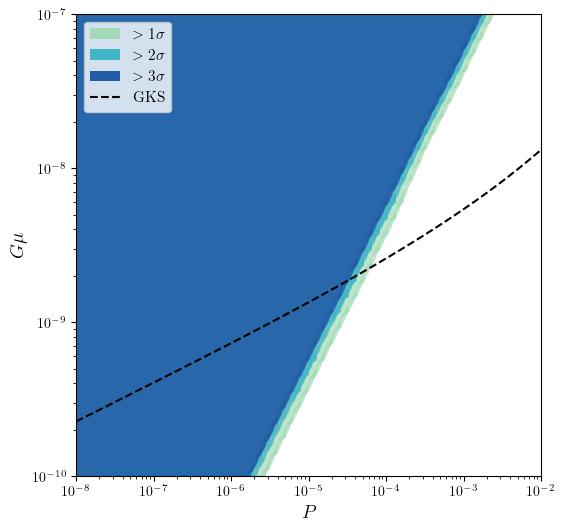

In [13]:

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Computer Modern Roman"]
# Create meshgrid
P_mesh, Gmu_mesh = np.meshgrid(P_grid, Gmu_grid)

fig, ax = plt.subplots(figsize=(6,6))

# ================================
# 1. EXCLUDED REGIONS 
# ================================
c1 = '#a1dab4'   # light (1σ)
c2 = '#41b6c4'   # medium (2σ)
c3 = '#225ea8'   # dark (3σ)

# Draw widest region first, then overlay narrower/darker regions on top
ax.contourf(P_mesh, Gmu_mesh, (delta_chi2 > 2.30).astype(float),
            levels=[0.5,1], colors=[c1], alpha=0.7)

ax.contourf(P_mesh, Gmu_mesh, (delta_chi2 > 6.17).astype(float),
            levels=[0.5,1], colors=[c2], alpha=0.8)

ax.contourf(P_mesh, Gmu_mesh, (delta_chi2 > 11.83).astype(float),
            levels=[0.5,1], colors=[c3], alpha=0.9)

# ================================
# 2. CONTOUR LINES
# ================================
cs = ax.contour(P_mesh, Gmu_mesh, delta_chi2,
                levels=[2.30, 6.17, 11.83],
                colors=[c1, c2, c3], alpha=[0.7, 0.8, 0.9], linewidths=3)

# ================================
# 3. EXTRACT 2σ LIMIT ON Gmu/P
# ================================
combo_grid = Gmu_mesh / P_mesh

mask_2sigma = delta_chi2 <= 6.17
combo_allowed = combo_grid[mask_2sigma]

# upper limit = max allowed value
combo_2sigma = np.max(combo_allowed)
combo_2sigma_n = np.float64(3.104590545296398e-05)
mantissa, exp = f"{combo_2sigma_n:.2e}".split("e")
constraint_latex = rf"$G\mu P^{{-1}} < {mantissa}\times 10^{{{int(exp)}}}$ (2$\sigma$)"

print(f"2\u03c3 constraint: G\u03bc/P < {combo_2sigma:.3e}")

# ================================
# 4. PLOT THIS CONSTRAINT LINE (clipped to grid range)
# ================================
P_line = np.logspace(-8, -2, 200)
Gmu_line = combo_2sigma * P_line

#ax.plot(P_line, Gmu_line, 'r--', lw=1.5, label=constraint_latex)
ax.plot(Pgks, Ggks/4, 'k--', label='GKS')

# ================================
# 5. LEGEND (paper style)
# ================================
legend_elements = [
    Patch(facecolor=c1, label=r'$>1\sigma$'),
    Patch(facecolor=c2, label=r'$>2\sigma$'),
    Patch(facecolor=c3, label=r'$>3\sigma$'),
    #Line2D([0], [0], color='red', linestyle='--', lw=1.5, label=constraint_latex),
    Line2D([0], [0], color='black', linestyle='--', lw=1.5, label='GKS')
]

ax.legend(handles=legend_elements, loc='upper left', fontsize=11)

# ================================
# 6. AXES FORMATTING
# ================================
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1e-8, 1e-2)
ax.set_ylim(1e-10, 1e-7)

ax.set_xlabel(r'$P$', fontsize=14)
ax.set_ylabel(r'$G\mu$', fontsize=14)


#ax.grid(alpha=0.2, which='both')

plt.savefig("plots/GmuP_Constraint_Plot.pdf", dpi=300, bbox_inches='tight')